<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/Fine_Tune_Images_PyTorch_Lightning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fine-Tuning de uma ResNet18 com PyTorch Lightning (PL)**

# 1. Preparação dos Dados CIFAR

In [ ]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 35.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.models import resnet18, ResNet18_Weights
from torchvision import transforms
import lightning.pytorch as pl
import numpy as np

# --- 1. Dados Mínimos Fictícios para Ilustração ---
class FictionalDataset(Dataset):
    def __init__(self, size=100):
        # Imagens: 3 canais (RGB), 32x32 pixels
        self.data = [torch.randn(3, 32, 32) for _ in range(size)]
        # Rótulos: 10 classes
        self.labels = [torch.randint(0, 10, (1,)).item() for _ in range(size)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# DataLoader: prepara os dados para o treinamento
train_dataset = FictionalDataset(size=200)
val_dataset = FictionalDataset(size=50)
train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

# 2. O LightningModule (O Coração do Modelo)

O LightningModule é onde definimos:

1. modelo,
2. função de perda,
3. otimizador e,
4. (mais importante) o ciclo de treinamento (training step) e de validação (validation step).

In [ ]:
## 🧠 Modelo de Visão com LightningModule
class VisionTuner(pl.LightningModule):
    def __init__(self, num_classes=10, learning_rate=1e-3):
        super().__init__()
        # Salva hiperparâmetros (útil para logging e checkpoint)
        self.save_hyperparameters()
        self.learning_rate = learning_rate

        # 1. Carregar ResNet18 Pré-treinada
        # Usamos os melhores pesos disponíveis (IMAGENET1K_V1)
        self.model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # 2. Fine-Tuning: Congelar Camadas (Opcional, mas comum)
        # Congelamos todos os parâmetros, exceto a camada final (fc)
        # for param in self.model.parameters():
        #     param.requires_grad = False

        # 3. Adaptar a Camada Final (Classifier)
        # Obter o número de features da camada final (geralmente 512 para ResNet18)
        num_ftrs = self.model.fc.in_features
        # Substituir a camada final por uma nova com `num_classes` saídas
        self.model.fc = nn.Linear(num_ftrs, num_classes)

        # Função de Perda
        self.criterion = nn.CrossEntropyLoss()

    # Define como a previsão (forward pass) é feita
    def forward(self, x):
        return self.model(x)

    # Define o que acontece em um único passo de treinamento (batch)
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Loga a perda (opcional)
        # self.log('train_loss', loss)

        # Mais que opcional... para o history!
        self.log('train_loss_epoch', loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    # Define o que acontece em um único passo de validação (batch)
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        # Calcula e loga a acurácia
        preds = torch.argmax(logits, dim=1)
        accuracy = (preds == y).float().mean()

        # Loga métricas
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', accuracy, prog_bar=True)
        return loss

    # Define o otimizador e o scheduler (se houver)
    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

# 3. O Trainer (Execução)

O Trainer é o componente que automatiza o loop de treinamento. Você especifica o modelo, a quantidade de épocas e se quer usar GPU.

In [ ]:
## 🚀 O Trainer: Automatizando o Treinamento
def run_fine_tuning():
    # 1. Inicializa o Modelo
    vision_model = VisionTuner(num_classes=10)

    # 2. Inicializa o Trainer
    # max_epochs=3: Apenas 3 passagens completas pelos dados de treino
    # accelerator='auto': Usa GPU se disponível, caso contrário, usa CPU
    # devices='auto': Usa todos os dispositivos disponíveis
    trainer = pl.Trainer(
        max_epochs=3,
        accelerator='auto',
        devices='auto',
        # Desativa o logging verboso para este exemplo didático?
        logger=True
    )

    print("Iniciando Fine-Tuning...")

    # 3. Inicia o Treinamento! (O PL cuida do loop)
    trainer.fit(vision_model, train_loader, val_loader)

    print("Fine-Tuning concluído!")
    print(f"Perda de Validação Final (aproximada): {trainer.callback_metrics.get('val_loss', 'N/A')}")
    print(f"Acurácia de Validação Final (aproximada): {trainer.callback_metrics.get('val_acc', 'N/A')}")



# 4. Run

In [ ]:
# Executa a função
run_fine_tuning()

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Iniciando Fine-Tuning...


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (7)
is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Fine-Tuning concluído!
Perda de Validação Final (aproximada): 2.59603214263916
Acurácia de Validação Final (aproximada): 0.11999999731779099


# 5. Predição

In [ ]:
import torch
import numpy as np
import random
# Assumimos que as classes FictionalDataset e VisionTuner estão definidas
# no ambiente (como no exemplo anterior)

# 1. Definição das classes (para interpretação do output)
CLASSES = ['avião', 'carro', 'pássaro', 'gato', 'cervo',
           'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

# 2. Re-inicializar o modelo e Trainer (necessário para o exemplo rodar)
vision_model = VisionTuner(num_classes=10)
trainer = pl.Trainer(max_epochs=10, accelerator='auto', devices='auto', logger=True)
trainer.fit(vision_model, train_loader, val_loader)

# Para o exemplo didático, usaremos o modelo inicial:
vision_model = VisionTuner(num_classes=10)

# 3. Preparar o modelo para inferência
vision_model.eval() # Coloca o modelo em modo de avaliação (desativa dropout, batch norm)
torch.set_grad_enabled(False) # Desativa o cálculo de gradientes

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (7)
is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you 
want to see logs for the training epoch.

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [ ]:
# 4. Amostra de Imagens
# Criamos um subconjunto dos dados de validação
sample_indices = random.sample(range(len(val_dataset)), k=4)
sample_images = []
sample_labels = []

for i in sample_indices:
    image, label_idx = val_dataset[i]
    sample_images.append(image)
    sample_labels.append(CLASSES[label_idx])

# Stack das imagens para formar um único tensor (batch_size=4)
input_batch = torch.stack(sample_images)

# 5. Realizar a Predição
# Passa o tensor pelo modelo (forward pass)
logits = vision_model(input_batch)

# 6. Processar o Output
# Converte os logits em probabilidades (opcional, mas bom para interpretar)
probabilities = torch.softmax(logits, dim=1)

# Pega o índice com a maior probabilidade para cada imagem
predicted_indices = torch.argmax(probabilities, dim=1)

# Converte os índices em nomes de classes
predicted_classes = [CLASSES[idx.item()] for idx in predicted_indices]

# 7. Imprimir Resultados
print("--- Predições do Modelo ---")
for i in range(4):
    true_label = sample_labels[i]
    predicted_label = predicted_classes[i]
    confidence = probabilities[i, predicted_indices[i]].item()

    print(f"Amostra {i+1}:")
    print(f"  Rótulo Verdadeiro: {true_label}")
    print(f"  Predição: {predicted_label} (Confiança: {confidence:.2f})")

--- Predições do Modelo ---
Amostra 1:
  Rótulo Verdadeiro: cervo
  Predição: avião (Confiança: 0.17)
Amostra 2:
  Rótulo Verdadeiro: navio
  Predição: avião (Confiança: 0.21)
Amostra 3:
  Rótulo Verdadeiro: carro
  Predição: avião (Confiança: 0.21)
Amostra 4:
  Rótulo Verdadeiro: gato
  Predição: avião (Confiança: 0.23)


# 6. History

In [ ]:
from lightning.pytorch.loggers import CSVLogger
import os # para gestão de diretórios

def run_fine_tuning_with_logging():
    vision_model = VisionTuner(num_classes=10)

    # 1. Inicializar o CSVLogger
    # Os logs serão salvos em './lightning_logs/my_resnet_logs/version_0/metrics.csv'
    logger = CSVLogger("lightning_logs", name="my_resnet_logs")

    # 2. Inicializar o Trainer com o logger
    trainer = pl.Trainer(
        max_epochs=10,
        accelerator='auto',
        devices='auto',
        logger=logger,        # <--- logger
        log_every_n_steps=2   # <--- logger
    )

    print(f"Logs salvos em: {os.path.join(logger.log_dir, 'metrics.csv')}")
    trainer.fit(vision_model, train_loader, val_loader)

run_fine_tuning_with_logging()

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Logs salvos em: lightning_logs/my_resnet_logs/version_4/metrics.csv


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 11.2 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 69                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
import pandas as pd
LOG_FILE_PATH = './lightning_logs/my_resnet_logs/version_0/metrics.csv'

try:
    metrics = pd.read_csv(LOG_FILE_PATH)
    display(metrics)
except FileNotFoundError:
    print(f"Erro: Arquivo de log não encontrado em {LOG_FILE_PATH}.")
    print("Execute o treinamento com o 'CSVLogger' ativado primeiro.")

,epoch,step,val_acc,val_loss
0,0,6,0.12,2.665124
1,1,13,0.04,2.507303
2,2,20,0.12,2.665829


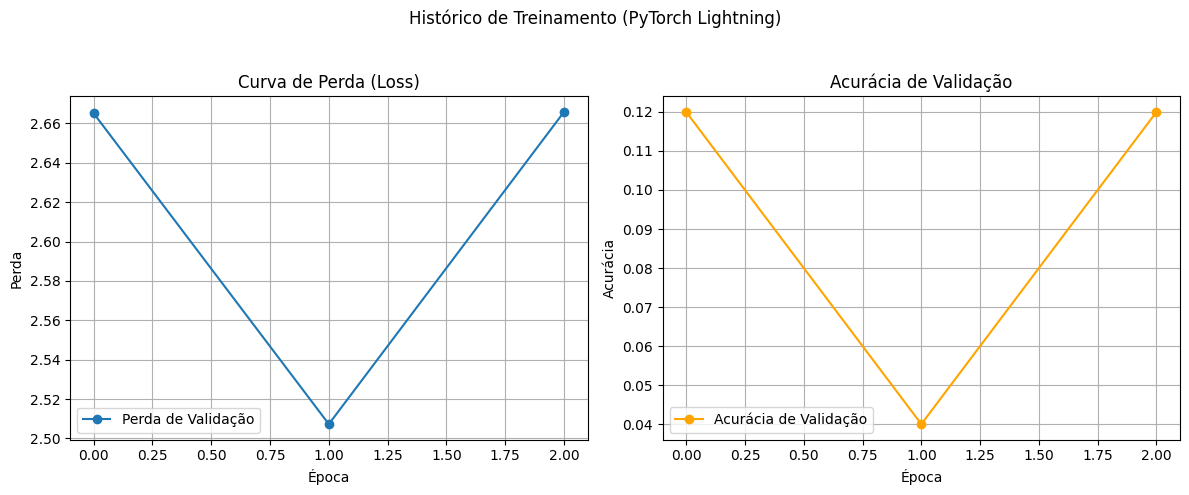

Gráfico 'training_history_plot.png' gerado com sucesso!


In [ ]:
import matplotlib.pyplot as plt

# ASSUMIMOS que o arquivo metrics.csv foi gerado e o caminho é:
LOG_FILE_PATH = './lightning_logs/my_resnet_logs/version_0/metrics.csv'

try:
    # 1. Carregar o arquivo de métricas
    metrics = pd.read_csv(LOG_FILE_PATH)

    # 2. Filtrar as métricas de interesse e remover NaNs
    # O CSVLogger salva todas as métricas em colunas separadas,
    # então precisamos de um pouco de processamento

    # Perda de Treinamento (train_loss)
    # train_loss = metrics.dropna(subset=['train_loss'])

    # Perda e Acurácia de Validação (val_loss, val_acc)
    val_metrics = metrics.dropna(subset=['val_loss', 'val_acc'])

    # 3. Gerar o Gráfico
    plt.figure(figsize=(12, 5))

    # Gráfico 1: Perda
    plt.subplot(1, 2, 1)
    # A perda de treino é registrada a cada passo, a de validação a cada época.
    # Usaremos os valores de época para a validação.
    # plt.plot(train_loss['epoch'], train_loss['train_loss'], label='Perda de Treinamento (Amostra)', alpha=0.6)
    plt.plot(val_metrics['epoch'], val_metrics['val_loss'], label='Perda de Validação', marker='o')
    plt.title('Curva de Perda (Loss)')
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()
    plt.grid(True)

    # Gráfico 2: Acurácia
    plt.subplot(1, 2, 2)
    plt.plot(val_metrics['epoch'], val_metrics['val_acc'], label='Acurácia de Validação', color='orange', marker='o')
    plt.title('Acurácia de Validação')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.grid(True)

    plt.suptitle('Histórico de Treinamento (PyTorch Lightning)')
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajusta layout para suptitle
    plt.savefig('training_history_plot.png')
    plt.show() # Em ambiente real, apenas savefig é usado

    print("Gráfico 'training_history_plot.png' gerado com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo de log não encontrado em {LOG_FILE_PATH}.")
    print("Execute o treinamento com o 'CSVLogger' ativado primeiro.")